In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

In [904]:
SAMPLE_SIZE = 500
NOISE_FACTOR = 0.05

In [905]:
def count_parameters(model):
    return sum(x.flatten().shape[0] for x in model.parameters() if hasattr(x, "shape"))


def render_graph(tensor, params=None):
    from torchviz import make_dot

    # Visualize the graph
    dot = make_dot(tensor, params=params)
    # Render the graph to a file (requires Graphviz installed on your system)
    dot.render("computational_graph", format="png")
    # Display in Jupyter Notebook (if using one)
    return dot

In [906]:
x = torch.linspace(-10, 10, SAMPLE_SIZE).unsqueeze(1)
noise = torch.randn(SAMPLE_SIZE).unsqueeze(1) * NOISE_FACTOR

In [907]:
def count_parameters(model):
    return sum(x.flatten().shape[0] for x in model.parameters() if hasattr(x, "shape"))

In [910]:
def function_linear(x, noise):
    return 0.123 * x + 0.234 + noise


def function_poly(x, noise):
    return 0.01 * x**2 + 0.05 * x + 1 + noise


def function_trig(x, noise):
    return torch.sin(x) + 0.5 * torch.cos(2 * x) + noise


def function_cmplx(x, noise):
    return torch.sin(torch.sqrt(x) ** 3) * torch.cos(x) - 0.05 * x ** (3 / 2) + noise

In [911]:
data_linear = x, function_linear(x, noise)
data_poly = x, function_poly(x, noise)
data_trig = x, function_trig(x, noise)
data_cmplx = x, function_cmplx(x, noise)

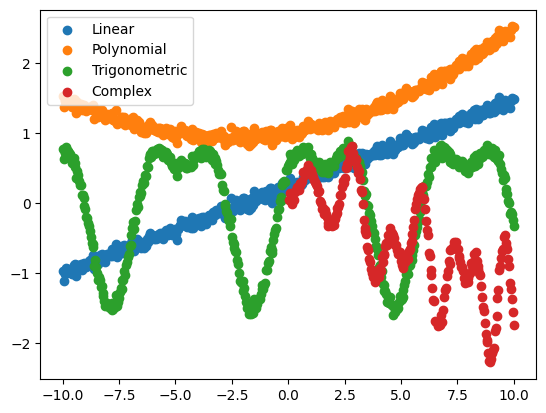

In [912]:
plt.scatter(*data_linear, label="Linear")
plt.scatter(*data_poly, label="Polynomial")
plt.scatter(*data_trig, label="Trigonometric")
plt.scatter(*data_cmplx, label="Complex")
plt.legend(loc="upper left")


In [913]:
class Model(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_dim, output_dim)
        # self.activation = nn.Tanh()

    def forward(self, x):
        x = self.fc1(x)
        # x = self.activation(x)
        return x

In [914]:
X, y = data_linear
N_FEATURES = X.shape[1]

In [915]:
print("x,y shapes:", X.shape, y.shape)
fc1 = nn.Linear(1, 1)
print(f"{fc1.weight.data.shape=}")
print(
    f"nn.Linear calculation : {X.shape=} @ {fc1.weight.data.T.shape=} + {fc1.bias.data.shape=}"
)
res1 = torch.matmul(X, fc1.weight.data.T) + fc1.bias.data
res2 = fc1(X)
print(res1.shape, res2.shape)
all(res1 == res2)

x,y shapes: torch.Size([500, 1]) torch.Size([500, 1])
fc1.weight.data.shape=torch.Size([1, 1])
nn.Linear calculation : X.shape=torch.Size([500, 1]) @ fc1.weight.data.T.shape=torch.Size([1, 1]) + fc1.bias.data.shape=torch.Size([1])
torch.Size([500, 1]) torch.Size([500, 1])


True

In [916]:
model = Model(input_dim=N_FEATURES, output_dim=1)

In [917]:
LEARNING_RATE = 0.005
MOMENTUM = 0.9
EPOCHS = 400  # 1.18 @ 240

In [918]:
criterion = torch.nn.MSELoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
count_parameters(model)

2

## Understanding the Training Loop Components

- `y = model(X)` : Calculate forward pass
- `loss = criterion(y_pred, y)` : Calculate loss
- `optimizer.zero_grad()`: Clear the `.grad` attribute of all parameters tracked by the optimizer
- `loss.backward()`: Calculate gradients for ALL DAG tensors with `requires_grad=True`. After that graph is freed unless `retain_graph=True`
- `optimizer.step()` : Updates parameters that are registered with the optimizer


## Performing Training Steps Once Manually


In [919]:
y_pred = model(X)
loss = criterion(y_pred, y)
optimizer.zero_grad()
loss.backward()

In [920]:
# before backpropagation update
print(f"{model.fc1.weight.data=}, {model.fc1.bias.data=}")
print(f"{model.fc1.weight.grad=}, {model.fc1.bias.grad=}")

model.fc1.weight.data=tensor([[0.4319]]), model.fc1.bias.data=tensor([-0.3344])
model.fc1.weight.grad=tensor([[20.6492]]), model.fc1.bias.grad=tensor([-1.1376])


In [921]:
# This calculation is assumes SGD - different optimizers follow different update schemes
print(f"new weights : {model.fc1.weight.data - model.fc1.weight.grad * LEARNING_RATE}")
print(f"new bias : {model.fc1.bias.data - model.fc1.bias.grad * LEARNING_RATE}")

new weights : tensor([[0.3287]])
new bias : tensor([-0.3288])


In [922]:
optimizer.step()
# after backpropagation update
print(f"{model.fc1.weight.data=}, {model.fc1.bias.data=}")
print()
print(f"{model.fc1.weight.grad=}, {model.fc1.bias.grad=}")

model.fc1.weight.data=tensor([[0.4269]]), model.fc1.bias.data=tensor([-0.3294])

model.fc1.weight.grad=tensor([[20.6492]]), model.fc1.bias.grad=tensor([-1.1376])


In [923]:
optimizer.zero_grad()
print(f"{model.fc1.weight.grad=}, {model.fc1.bias.grad=}")

model.fc1.weight.grad=None, model.fc1.bias.grad=None


## Training using the EPOCHS Loop


In [924]:
A = []
L = []
model.train()  # set the model to training mode

for epoch in range(EPOCHS):
    y_pred = model(x)
    # loss
    loss = criterion(y_pred, y)
    # zero gradient
    optimizer.zero_grad()
    # backward
    loss.backward()
    # update weights
    optimizer.step()
    # log metrics
    L.append(loss.item())
    # print epoch statistics
    if epoch % 10 == 0:
        print(f"{epoch=} loss : {loss:.2f}")

epoch=0 loss : 3.40
epoch=10 loss : 2.42
epoch=20 loss : 1.64
epoch=30 loss : 1.06
epoch=40 loss : 0.65
epoch=50 loss : 0.38
epoch=60 loss : 0.22
epoch=70 loss : 0.12
epoch=80 loss : 0.07
epoch=90 loss : 0.05
epoch=100 loss : 0.03
epoch=110 loss : 0.02
epoch=120 loss : 0.02
epoch=130 loss : 0.01
epoch=140 loss : 0.01
epoch=150 loss : 0.01
epoch=160 loss : 0.01
epoch=170 loss : 0.00
epoch=180 loss : 0.00
epoch=190 loss : 0.00
epoch=200 loss : 0.00
epoch=210 loss : 0.00
epoch=220 loss : 0.00
epoch=230 loss : 0.00
epoch=240 loss : 0.00
epoch=250 loss : 0.00
epoch=260 loss : 0.00
epoch=270 loss : 0.00
epoch=280 loss : 0.00
epoch=290 loss : 0.00
epoch=300 loss : 0.00
epoch=310 loss : 0.00
epoch=320 loss : 0.00
epoch=330 loss : 0.00
epoch=340 loss : 0.00
epoch=350 loss : 0.00
epoch=360 loss : 0.00
epoch=370 loss : 0.00
epoch=380 loss : 0.00
epoch=390 loss : 0.00


In [925]:
model.fc1.weight.data, model.fc1.bias.data

(tensor([[0.1234]]), tensor([0.2344]))

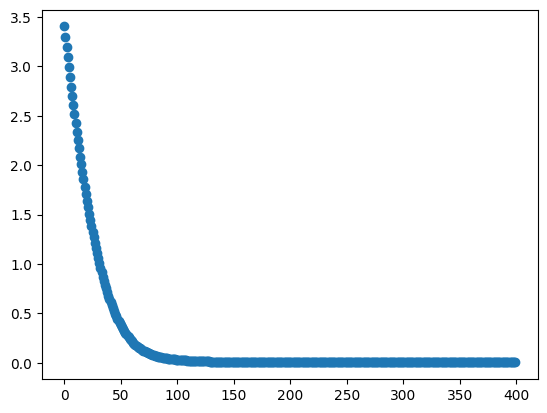

In [926]:
plt.scatter(list(range(EPOCHS)), L)

In [929]:
predictions = model(X).detach().numpy()
y_true = y.detach().numpy()
np.mean(y_true - predictions).item()

1.1232137694605626e-05

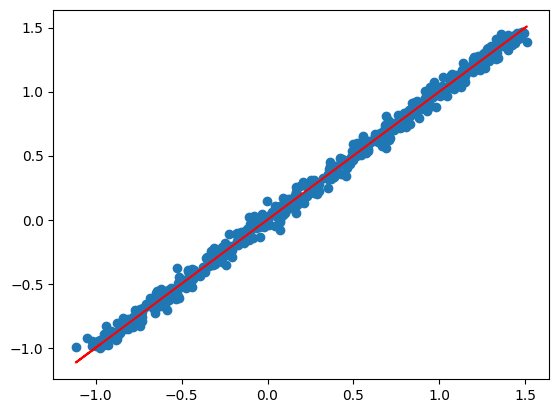

In [933]:
plt.scatter(y, predictions)
plt.plot(y, y, "r-")